    # OVERALL WE WILL BE DOING THIS

* preprocess+ EDA + feature seection
* extract input and output columns
* scale the values
* train test split
* train the model
* evaluate the model/modelselection
* deploy the model

In [56]:
import pandas as pd
import numpy as np

In [57]:
df=pd.read_csv("placement.csv")

In [58]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.1,84.4,0
1,1,9.2,169.1,1
2,2,8.0,124.0,1
3,3,7.3,151.2,1
4,4,4.9,207.1,1


In [59]:
df.info() #it gives us info about every column wheather is it empty or not

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [60]:
df.shape

(100, 4)

In [61]:
df=df.iloc[:,1:]

In [62]:
df

,cgpa,iq,placement
0,6.1,84.4,0
1,9.2,169.1,1
2,8.0,124.0,1
3,7.3,151.2,1
4,4.9,207.1,1
...,...,...,...
95,6.7,128.9,1
96,6.9,181.6,1
97,6.4,205.6,1
98,4.1,204.2,0


In [63]:
import matplotlib.pyplot as plt


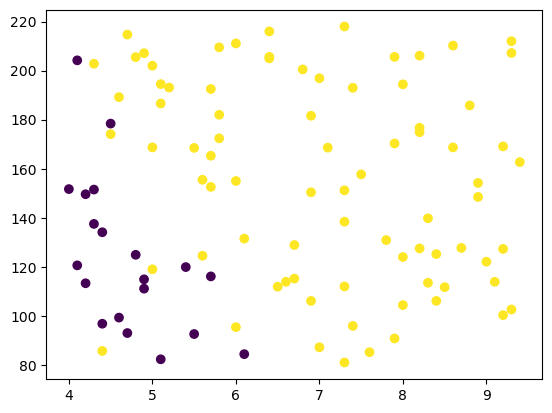

In [64]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement']) #x axis pe cgpa aur y axis pe iq yellow walo logo ka placement ho gya 

# Logistic Regressionn 

## logisctic regression ek classification algorithm hai. jab hume kisi cheez ko do classes me divide karna hota hai (jaise yes/no , pass/fail,0 ya 1 ) tab hum iska use karte hai 

## ye ek s shaped curve (sigmoid curve) banata hai jo output ko 0 aur 1 ki beech probability me convert kar deta hai 
## agar probability 0.5 se zyada output=class1 aur agar 0.5 se kam toh class 0
## asal me s curve background me banta hai 2d me toh ek line banti hai 


### we are using it here beause 
* hamare paaas 2 classes hai : **purple dotes** aur **yellow dots**
* ye model in dono classes ke beech ek **straight line(decision boundary)** draw krega jo inko alag-alag divide kregi  

### cgpa and iq are independent variables and placement is our dependent variable s it is depending on our cgpa and iq

In [65]:
x=df.iloc[:,0:2] #isme saare independet variable stored hai 
y=df.iloc[:,-1]  #isme saare dependent variables stored hai

In [66]:
x

,cgpa,iq
0,6.1,84.4
1,9.2,169.1
2,8.0,124.0
3,7.3,151.2
4,4.9,207.1
...,...,...
95,6.7,128.9
96,6.9,181.6
97,6.4,205.6
98,4.1,204.2


In [67]:
y

0     0
1     1
2     1
3     1
4     1
     ..
95    1
96    1
97    1
98    0
99    1
Name: placement, Length: 100, dtype: int64

In [68]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1)

In [69]:
x_train #randomly 90 rows aur 2 columns training data me chala gya 

,cgpa,iq
64,5.5,92.6
31,4.9,111.1
73,8.5,111.7
82,5.8,209.5
51,8.3,113.5
...,...,...
11,9.3,102.6
85,5.8,172.4
87,7.5,157.7
66,4.8,124.9


* test_size=0.1-- 90% data ko training aur 10% data ko testing ke liye split kar rha hai
* x_train , y_train -- model ko train karne ke liye inputs aur outputs
* x_test,y_test-- trained mode l ki accuracy test karne ke liye

In [70]:
y_train

64    0
31    0
73    1
82    1
51    1
     ..
11    1
85    1
87    1
66    0
70    1
Name: placement, Length: 90, dtype: int64

In [71]:
from sklearn.preprocessing import StandardScaler

In [75]:
scaler=StandardScaler()

In [77]:
x_train=scaler.fit_transform(x_train)

In [78]:
x_train

array([[-0.65966905, -1.41463719],
       [-1.02502421, -0.94984697],
       [ 1.16710677, -0.9347727 ],
       [-0.47699146,  1.52233453],
       [ 1.04532172, -0.88954986],
       [ 1.59335447, -0.54284148],
       [-1.57305696,  0.07017914],
       [ 0.80175161,  0.53748174],
       [ 0.86264414,  1.14296522],
       [ 1.47156941, -0.67348522],
       [ 0.43639645,  0.05761724],
       [-0.96413168,  0.49728366],
       [ 0.19282634, -1.07546595],
       [-1.20770179,  1.01232148],
       [-0.47699146,  0.83143015],
       [-1.02502421, -0.85437655],
       [ 0.74085908, -0.45239582],
       [-0.1116363 ,  1.42435173],
       [-1.51216443,  1.38917841],
       [-0.65966905,  0.49225891],
       [-0.53788399, -0.82422799],
       [-0.53788399,  0.41186276],
       [ 1.59335447,  0.50733318],
       [ 0.61907403, -1.60055328],
       [-0.84234663,  1.11030428],
       [ 0.19282634,  0.82138063],
       [ 1.28889183, -0.53279196],
       [ 0.19282634,  0.0375182 ],
       [-0.53788399,

# WHY DO WE SCALE DATA ??

* ML ALGORITHMS USE MATHEMATICAL DISTANCES
* IF FEATUES HAVE DIFFERENT RANGES (EG CGPA 0-10 AND IQ-70-150
* 

In [20]:
x_test=scaler.transform(x_test)
x_test

array([[ 1.05464123, -0.54288408],
       [ 0.30725768,  1.14368839],
       [-1.3743553 ,  1.28707135],
       [ 0.12041179, -0.8418011 ],
       [ 0.24497572,  0.77186478],
       [ 1.73974281, -1.14800878],
       [ 1.55289693, -0.67411594],
       [-1.00066353, -0.84909176],
       [ 0.55638553,  1.04890982],
       [ 1.67746085, -0.54774452]])

In [21]:
from sklearn.linear_model import LogisticRegression

In [22]:
clf=LogisticRegression()

In [23]:
clf.fit(x_train,y_train) #yahi model training hai 

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [25]:
y_pred=clf.predict(x_test) #clf.predict ko hum xtest dete hai toh hume yeh y predicrt kar ke deta hai 

In [26]:
y_pred


array([1, 1, 1, 1, 1, 1, 1, 0, 1, 1])

In [27]:
y_test

94    1
65    1
83    1
41    1
96    1
11    1
43    1
5     0
20    1
33    1
Name: placement, dtype: int64

In [28]:
from sklearn.metrics import accuracy_score

In [29]:
accuracy_score(y_test,y_pred)

1.0